In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Đọc file data
df = pd.read_csv('./data/data_raw.csv')
# Xem qua 5 dòng đầu
df.head()

FileNotFoundError: [Errno 2] No such file or directory: './data/data_raw.csv'

## XỬ LÝ MISSING


In [ ]:
# Tính toán số lượng và tỷ lệ % missing
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Total Missing': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

# Chỉ hiển thị các cột có missing
print(missing_report[missing_report['Total Missing'] > 0])

                    Total Missing  Percentage (%)
Study Satisfaction         112803       80.172708
Academic Pressure          112803       80.172708
CGPA                       112802       80.171997
Profession                  36630       26.034115
Work Pressure               27918       19.842217
Job Satisfaction            27910       19.836532
Financial Stress                4        0.002843
Dietary Habits                  4        0.002843
Degree                          2        0.001421


Do các thông số của Student sẽ không có dữ liệu liên quan đến dữ liệu của Working Professional và ngược lại nên sẽ xảy ra hiện tượng cột Student và Working Professional có tỉ lệ missing lớn.
- Điền giá trị mặc định cho các thuộc tính không tương ứng (điền 0 vào các chỉ số của sinh viên và ngược lại)
- Biến CGPA: Áp dụng giá trị -1 cho nhóm Người đi làm để tách biệt hoàn toàn với thang điểm thực tế ($0 \leq CGPA \leq 10$)


In [ ]:
# Xử lý profession
def handle_profession(row):
    if pd.isnull(row['Profession']):
        if row['Working Professional or Student'] == 'Student':
            return 'Student'
        elif row['Working Professional or Student'] == 'Working Professional':
            return 'Other'
    return row['Profession']

df['Profession'] = df.apply(handle_profession, axis=1)

In [ ]:
# --- BƯỚC 2: XỬ LÝ CÓ ĐIỀU KIỆN (Điền 0 cho nhóm đối nghịch)  ---

# Nhóm Học tập: WP thì điền 0 (vì WP không có dữ liệu học tập)
# Đặc biệt: với CGPA fill -1 do CGPA nằm trong khoảng từ 0-10 nhằm đảm bảo không gây ảnh hưởng dữ liệu
study_cols = ['CGPA', 'Academic Pressure', 'Study Satisfaction']

for col in study_cols:
    if col == 'CGPA':
        fill_val = -1
    else:
        fill_val = 0

    df.loc[(df['Working Professional or Student'] == 'Working Professional') & (df[col].isnull()), col] = fill_val

# Nhóm Công việc: ST thì điền 0 (vì ST không có dữ liệu công việc)
work_cols = ['Work Pressure', 'Job Satisfaction']
for col in work_cols:
    df.loc[(df['Working Professional or Student'] == 'Student') & (df[col].isnull()), col] = 0

Lọc dữ liệu: Loại bỏ các dòng có tỷ lệ thiếu hụt thấp (< 1%) ở các cột định danh và thói quen sinh hoạt để đảm bảo tính nguyên vẹn của dữ liệu đầu vào.

In [ ]:
# --- BƯỚC 3: XỬ LÝ CÁC CỘT THIẾU ÍT < 1%  ---
minor_missing_cols = ['Financial Stress', 'Dietary Habits', 'Degree']
df.dropna(subset=minor_missing_cols, inplace=True)

In [ ]:
# --- BƯỚC 4: KIỂM TRA VÀ XÓA DÒNG ---

# Nếu là WP mà vẫn thiếu dữ liệu WP (như Work Pressure, Job Satisfaction) -> Xóa
df.dropna(subset=work_cols, inplace=True)

# Nếu là ST mà vẫn thiếu dữ liệu ST (như CGPA, Academic Pressure...) -> Xóa
df.dropna(subset=study_cols, inplace=True)

In [ ]:
# Đếm số lượng dòng có ít nhất một giá trị null sau khi xử lý
count_null_rows = df.isnull().any(axis=1).sum()
print(f"Tổng số dòng bị null là: {count_null_rows}")
# Lưu lại dữ liệu mới sau xử lý
df.to_csv('data_final.csv', index=False)

Tổng số dòng bị null là: 0


In [ ]:
# Loại bỏ những dòng: (Profession == 'Student') VÀ (Working Professional or Student == 'Working Professional')

df = df.drop(df[(df['Profession'] == 'Student') &
                (df['Working Professional or Student'] == 'Working Professional')].index)

## XỬ LÝ NGOẠI LAI


Áp dụng thuật toán Interquartile Range (IQR) để tìm và xử lý ngoại lai.

In [ ]:
# Nhóm các biến đánh giá theo thang điểm (0 - 5)
scale_cols = [
    'Academic Pressure', 'Work Pressure',
    'Study Satisfaction', 'Job Satisfaction',
    'Financial Stress'
]

# Nhóm các biến định lượng có giá trị tự do
quantity_cols = ['Age', 'Work/Study Hours', 'CGPA']

print("--- BÁO CÁO KIỂM TRA DỮ LIỆU NGOẠI LAI ---\n")

# --- PHẦN 1: KIỂM TRA THEO MIỀN GIÁ TRỊ (Dành cho nhóm Thang điểm) ---
# Mục tiêu: Phát hiện các giá trị nhập sai nằm ngoài khoảng quy định 0-5
for col in scale_cols:
    if col in df.columns:
        invalid = df[(df[col] < 0) | (df[col] > 5)]
        print(f"[*] {col:20}: Có {len(invalid):3} dòng nằm ngoài vùng 0-5")

# --- PHẦN 2: KIỂM TRA THEO PHƯƠNG PHÁP IQR (Dành cho nhóm Định lượng) ---
# Mục tiêu: Xác định các giá trị bất thường dựa trên phân phối dữ liệu thực tế
for col in quantity_cols:
    if col in df.columns:
        # Chỉ tính toán dựa trên các giá trị lớn hơn 0 để tránh nhiễu
        valid_data = df[df[col] > 0][col]

        if not valid_data.empty:
            Q1 = valid_data.quantile(0.25)
            Q3 = valid_data.quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            # Xác định các dòng là ngoại lai
            outliers = df[(df[col] > 0) & ((df[col] < lower) | (df[col] > upper))]
            print(f"[*] {col:20}: Phát hiện {len(outliers):3} dòng ngoại lai (Ngưỡng trên: {upper:.2f})")

            # XỬ LÝ: Sử dụng kỹ thuật Capping (Clip) để giới hạn giá trị ngoại lai
            # Giữ mức tối thiểu là 0 và mức tối đa là ngưỡng upper của IQR
            if col == 'CGPA':
              df.loc[df[col] > 0, col] = df.loc[df[col] > 0, col].clip(upper=upper)
            else:
              df[col] = df[col].clip(lower=0, upper=upper)


--- BÁO CÁO KIỂM TRA DỮ LIỆU NGOẠI LAI ---

[*] Academic Pressure   : Có   0 dòng nằm ngoài vùng 0-5
[*] Work Pressure       : Có   0 dòng nằm ngoài vùng 0-5
[*] Study Satisfaction  : Có   0 dòng nằm ngoài vùng 0-5
[*] Job Satisfaction    : Có   0 dòng nằm ngoài vùng 0-5
[*] Financial Stress    : Có   0 dòng nằm ngoài vùng 0-5
[*] Age                 : Phát hiện   0 dòng ngoại lai (Ngưỡng trên: 84.00)
[*] Work/Study Hours    : Phát hiện   0 dòng ngoại lai (Ngưỡng trên: 19.00)
[*] CGPA                : Phát hiện   0 dòng ngoại lai (Ngưỡng trên: 12.87)


C:\Users\dell\AppData\Local\Temp\ipykernel_15260\2727327403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')


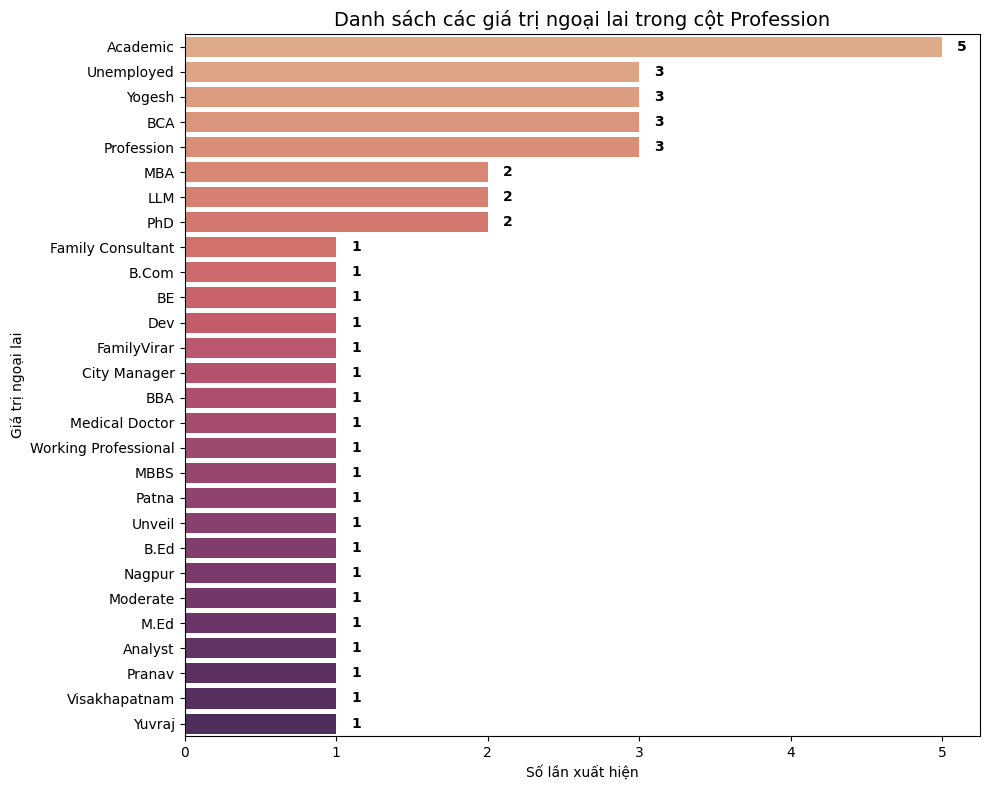

In [ ]:
# Kiểm tra ngoại lai ở cột Profession
col = 'Profession'
counts = df[col].value_counts()

# Lọc lấy những giá trị có số lần xuất hiện từ 1 đến 20 (nhóm ngoại lai)
outlier_side = counts[counts <= 20]

plt.figure(figsize=(10, 8))
sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')

for i, v in enumerate(outlier_side.values):
  plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.title(f'Danh sách các giá trị ngoại lai trong cột {col}', fontsize=14)
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Giá trị ngoại lai')
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý ngoại lai ở cột Profession
# Danh sách dữ liệu cần phải xóa vì nó không phải nghề nghiệp
invalid_to_other = [
    'Yogesh', 'Patna', 'Nagpur', 'Visakhapatnam', 'Pranav', 'Yuvraj',
    'Profession', 'Unveil', 'Moderate', 'BCA', 'MBA', 'PhD', 'LLM',
    'B.Ed', 'M.Ed', 'B.Com', 'BBA', 'MBBS', 'BE', 'FamilyVirar'
]

def clean_only_trash(x):
    if x in invalid_to_other:
        return 'Other'
    return x

df['Profession'] = df['Profession'].apply(clean_only_trash)

# Kiểm tra lại số lượng sau khi xóa
print(df['Profession'].value_counts())


Profession
Student                   27851
Teacher                   24906
Other                      8766
Content Writer             7813
Architect                  4370
Consultant                 4228
HR Manager                 4022
Pharmacist                 3893
Doctor                     3255
Business Analyst           3161
Entrepreneur               2968
Chemist                    2967
Chef                       2862
Educational Consultant     2852
Data Scientist             2390
Researcher                 2328
Lawyer                     2212
Customer Support           2055
Marketing Manager          1976
Pilot                      1913
Travel Consultant          1860
Plumber                    1748
Sales Executive            1739
Manager                    1737
Judge                      1712
Electrician                1582
Financial Analyst          1574
Software Engineer          1510
Civil Engineer             1469
UX/UI Designer             1452
Digital Marketer           13

C:\Users\dell\AppData\Local\Temp\ipykernel_15260\4131371632.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')


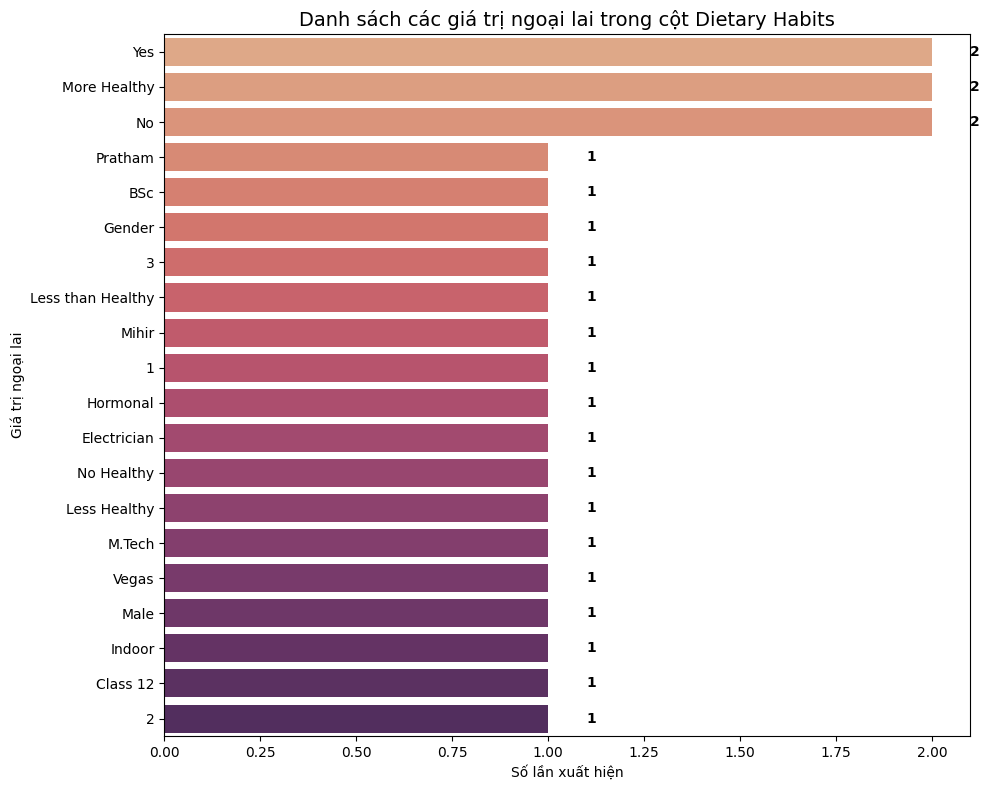

In [ ]:
# Kiểm tra ngoại lai ở cột Dietary Habits
col = 'Dietary Habits'
counts = df[col].value_counts()

# Lọc lấy những giá trị có số lần xuất hiện từ 1 đến 20 (nhóm ngoại lai)
outlier_side = counts[counts <= 20]

plt.figure(figsize=(10, 8))
sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')

for i, v in enumerate(outlier_side.values):
  plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.title(f'Danh sách các giá trị ngoại lai trong cột {col}', fontsize=14)
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Giá trị ngoại lai')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Danh sách cần xóa
danh_sach_delete = [
    'Yes', 'No', 'Pratham', 'Gender', 'BSc', '3', '1.0',
    'Hormonal', 'Electrician', 'Mihir', 'M.Tech', 'Vegas',
    'Male', 'Indoor', 'Class 12', '2'
]

# 2. Xóa các dòng có giá trị nằm trong danh sách trên
ten_cot_dung = 'Dietary Habits'

# Lệnh này giữ lại những dòng KHÔNG nằm trong danh sách rác
df = df[~df[ten_cot_dung].isin(danh_sach_delete)].copy()

# 3. Kiểm tra lại kết quả
print("Các giá trị thói quen ăn uống còn lại:")
print(df[ten_cot_dung].value_counts())

Các giá trị thói quen ăn uống còn lại:
Dietary Habits
Moderate             49681
Unhealthy            46213
Healthy              44730
More Healthy             2
Less than Healthy        1
1                        1
No Healthy               1
Less Healthy             1
Name: count, dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_15260\1536659800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')


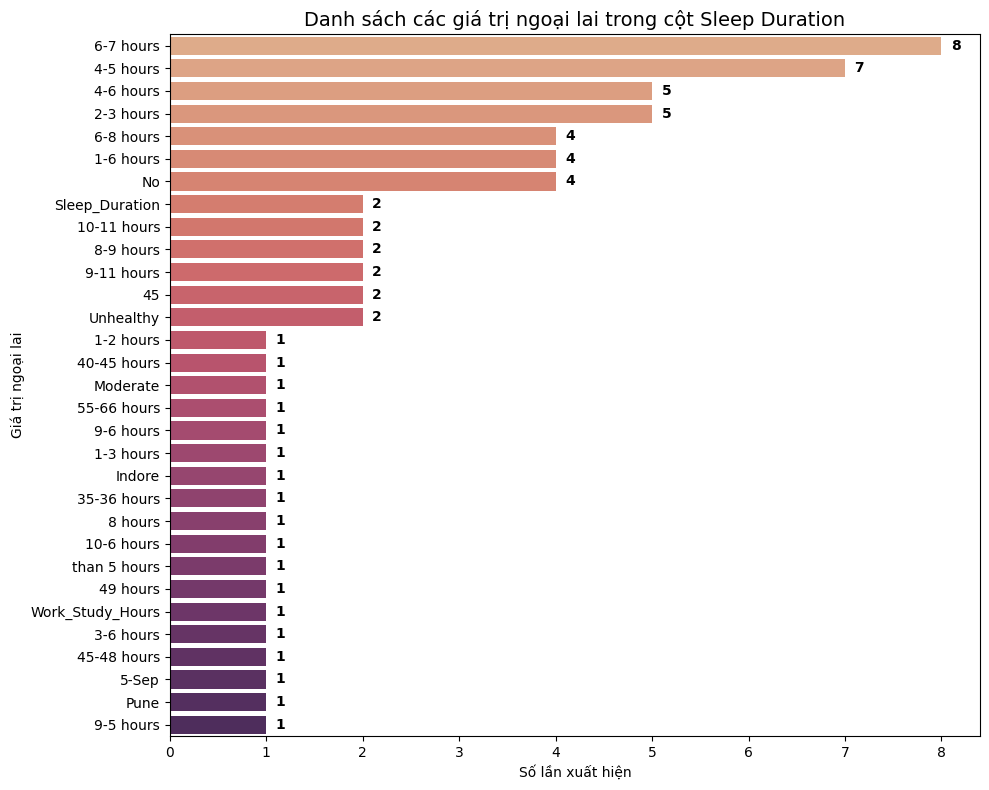

In [ ]:
# Kiểm tra ngoại lai ở cột Sleep Duration
col = 'Sleep Duration'
counts = df[col].value_counts()

# Lọc lấy những giá trị có số lần xuất hiện từ 1 đến 10 (nhóm ngoại lai)
outlier_side = counts[counts <= 10]

plt.figure(figsize=(10, 8))
sns.barplot(x=outlier_side.values, y=outlier_side.index, palette='flare')

for i, v in enumerate(outlier_side.values):
  plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.title(f'Danh sách các giá trị ngoại lai trong cột {col}', fontsize=14)
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Giá trị ngoại lai')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Danh sách cần xóa
danh_sach_delete_sleep = [
    'No', 'Unhealthy', 'Moderate', '40-45 hours', 'Sleep_Duration',
    'than 5 hours', 'Work_Study_Hours', '45-48 hours', 'Pune', 'Indore', '45', '35-36 hours', '49 hours', '55-66 hours', '9-5'
]

col_sleep = 'Sleep Duration'

# 2. Lọc bỏ: Chỉ giữ lại những dòng có giá trị thói quen ngủ thực sự
df = df[~df[col_sleep].isin(danh_sach_delete_sleep)].copy()

# 3. Reset index cho dữ liệu chuẩn chỉnh
df = df.reset_index(drop=True)

# 4. Kiểm tra kết quả
print("Các giá trị thời gian ngủ còn lại:")
print(df[col_sleep].unique())

Các giá trị thời gian ngủ còn lại:
<StringArray>
['More than 8 hours', 'Less than 5 hours',         '5-6 hours',
         '7-8 hours',         '1-2 hours',         '6-8 hours',
         '4-6 hours',         '6-7 hours',       '10-11 hours',
         '8-9 hours',        '9-11 hours',         '2-3 hours',
         '3-4 hours',         '4-5 hours',         '9-6 hours',
         '1-3 hours',         '1-6 hours',           '8 hours',
        '10-6 hours',         '3-6 hours',             '5-Sep',
         '9-5 hours']
Length: 22, dtype: str


In [ ]:
print(f"\nTổng số dòng còn lại sau khi xử lý: {len(df)}")


Tổng số dòng còn lại sau khi xử lý: 140610


## CHUẨN HÓA DỮ LIỆU

In [ ]:
# Hàm hiển thị toàn bộ giá trị duy nhất của các cột dạng chữ
print("DANH SÁCH GIÁ TRỊ CHI TIẾT:\n")
for col in df.select_dtypes(include=['object']).columns:
    if col not in ['Name']: # Bỏ qua cột Tên vì quá dài
        print(f"--- Cột: {col} ---")
        print(df[col].unique())
        print(f"Số lượng giá trị duy nhất: {df[col].nunique()}\n")

# Hàm hiển thị thống kê cột số
print("THỐNG KÊ CỘT SỐ:")
print(df.describe().loc[['min', 'max']])

DANH SÁCH GIÁ TRỊ CHI TIẾT:

--- Cột: Gender ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Số lượng giá trị duy nhất: 2

--- Cột: City ---
<StringArray>
[          'Ludhiana',           'Varanasi',      'Visakhapatnam',
             'Mumbai',             'Kanpur',          'Ahmedabad',
              'Thane',             'Nashik',          'Bangalore',
              'Patna',             'Rajkot',             'Jaipur',
               'Pune',            'Lucknow',             'Meerut',
               'Agra',              'Surat',          'Faridabad',
          'Hyderabad',           'Srinagar',          'Ghaziabad',
            'Kolkata',            'Chennai',             'Kalyan',
             'Nagpur',           'Vadodara',        'Vasai-Virar',
              'Delhi',             'Bhopal',             'Indore',
          'Ishanabad',              'Vidhi',              'Ayush',
            'Gurgaon',            'Krishna',          'Aishwarya',
             'Keshav',        

C:\Users\dell\AppData\Local\Temp\ipykernel_15260\4169120447.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


- Dữ liệu ở cột Sleep Duration tồn tại dưới dạng chuỗi văn bản hỗn loạn và không đồng nhất chuyển đổi về thang đo thứ bậc từ 1 đến 5

In [ ]:
# Chuẩn hóa dữ liệu ở cột Sleep Duration
sleep_mapping = {
    # Mức 1: Rất ít
    '1-2 hours': 1, '1-3 hours': 1, '2-3 hours': 1, '3-4 hours': 1,
    # Mức 2: Thiếu ngủ
    '4-5 hours': 2, '4-6 hours': 2, '5-6 hours': 2, 'Less than 5 hours': 2, '1-6 hours': 2, '3-6 hours': 2,
    # Mức 3: Trung bình
    '6-7 hours': 3, '6-8 hours': 3,
    # Mức 4: Lý tưởng (Trạng thái tốt nhất)
    '7-8 hours': 4, '8-9 hours': 4, '8 hours': 4, '9-5 hours': 4, '9-6 hours': 4, '10-6 hours': 4,
    # Mức 5: Ngủ quá nhiều
    '9-11 hours': 5, '10-11 hours': 5, 'More than 8 hours': 5
}

# Tạo cột mới sau khi chuẩn hóa
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_mapping)

# Kiểm tra kết quả
print("Thông kê sau chuẩn hóa:")
print(df['Sleep Duration'].value_counts().sort_index())

Thông kê sau chuẩn hóa:
Sleep Duration
1.0       19
2.0    70899
3.0       12
4.0    36959
5.0    32720
Name: count, dtype: int64


- Dữ liệu cột Dietary Habits mô tả nhiều ý, gây ra sự nhiễu và làm loãng ý nghĩa của các đặc trưng do đó tiến hành tái cấu trúc biến này thành 3 nhóm chính.

In [ ]:
# Chuẩn hóa dữ liệu ở cột Dietary Habits
# Định nghĩa từ điển chuyển đổi
diet_mapping = {
    'Healthy': 'Healthy',
    'More Healthy': 'Healthy',
    'Moderate': 'Moderate',
    'Less than Healthy': 'Moderate',
    'Less Healthy': 'Moderate',
    'Unhealthy': 'Unhealthy',
    'No Healthy': 'Unhealthy'
}

# Thực hiện chuyển đổi trực tiếp trên cột cũ hoặc tạo cột mới
df['Dietary Habits'] = df['Dietary Habits'].map(diet_mapping)

# Kiểm tra lại kết quả
print("Phân phối dữ liệu sau khi gộp nhóm:")
print(df['Dietary Habits'].value_counts())

Phân phối dữ liệu sau khi gộp nhóm:
Dietary Habits
Moderate     49676
Unhealthy    46207
Healthy      44726
Name: count, dtype: int64


In [ ]:
print(f"\nTổng số dòng còn lại sau khi xử lý: {len(df)}")
df.to_csv('./data/data_cleaned.csv', index=False)


Tổng số dòng còn lại sau khi xử lý: 140610
